# Processing of the FDL proteomics data
Preprocessing of the FDL proteomics data for cohort 1 from the Federated Deep learning study (https://doi.org/10.1158/2159-8290.CD-24-1488https://doi.org/10.1158/2159-8290.CD-24-1488). This is a DIANN-processed, pan-cancer, DIA data of patient tissues, encompassing tumors, adjacent normal, and healthy tissues (n = 1260 in total). This data shares the MS machine and MS condition as the cell line ones. Here data from all tissues were saved. But when merging data, only tumor tissues will be kept for the analysis.


In [ ]:
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import umap
import yaml

In [ ]:
with open("../../config/config.local.yaml", "r") as f:
    config = yaml.safe_load(f)
basedir = config['code_dir']

data_input_dir = config["tumor_data_dir"]
tumor_data_filename = config["tumor_data_filename"]

data_output_dir = os.path.join(config["output_data_dir"], "processed_proteomics_data")
if not os.path.exists(data_output_dir):
    os.makedirs(data_output_dir)

In [ ]:
proteome_df = pd.read_csv(os.path.join(data_input_dir, tumor_data_filename), sep="\t", index_col=0, decimal=",")
proteome_df.head()

/tmp/ipykernel_1191892/2660908813.py:1: DtypeWarning: Columns (6,12,19,20,63,73,84,112,115,125,158,163,181,194,206,215,218,231,248,270,286,298,304,305,307,334,345,351,352,363,373,376,378,382,391,408,411,417,419,423,426,437,445,449,478,481,483,487,496,497,501,508,512,517,518,519,520,525,534,536,538,558,559,563,564,572,579,594,597,613,637,648,657,660,663,673,679,689,697,706,708,719,725,743,756,758,759,769,777,780,832,855,859,869,870,874,885,888,894,907,909,930,938,946,948,950,964,976,981,997,1021,1029,1030,1040,1056,1085,1100,1111,1112,1126,1153,1157,1162,1169,1170,1171,1172,1182,1189,1191,1198,1200,1201,1207,1218,1219,1220,1223,1225,1240,1246,1272,1274,1278,1279,1280,1282,1286,1293,1302,1327,1329,1335,1339,1354,1369,1374,1375,1378,1391,1396,1401,1404,1410,1421,1431,1476,1480,1483,1493,1494,1496,1505,1513,1527,1532,1542,1549,1553,1565,1570,1585,1587,1590,1599,1603,1604,1624,1629,1635,1639,1643,1672,1690,1700,1704,1708,1714,1728,1735,1750,1769,1793,1795,1812,1822,1824,1835,1843,1851,1854,

,Cancer type,Tissue type,Cancer subtype,P37108,Q96JP5,Q8N697,P36578,O76031,A6NIH7,Q9BTD8,...,Q96DU7,P56645,P16109,Q9Y5R5,Q9BZE2,Q969E3,O75419,P0C221,Q92963,P51692
SampleID,,,,,,,,,,,,,,,,,,,,,
00J63,Normal,Adipose tissue,Normal_adipose_tissue,5.269742755,NaN,NaN,7.550818742,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.661501187,NaN,NaN
00J5Z,Normal,Adipose tissue,Normal_adipose_tissue,4.412176306,1.803226674,NaN,6.713835791,NaN,NaN,NaN,...,NaN,NaN,NaN,9.414878889,NaN,NaN,NaN,6.169062079,NaN,NaN
00G65,Normal,Adipose tissue,Normal_adipose_tissue,4.805441924,NaN,NaN,7.271449247,NaN,1.981005873,NaN,...,NaN,NaN,NaN,8.700540495,NaN,NaN,NaN,NaN,NaN,NaN
00G5X,Normal,Adipose tissue,Normal_adipose_tissue,4.53860255,NaN,NaN,6.682216983,NaN,NaN,NaN,...,NaN,NaN,5.004522411,9.189080546,NaN,NaN,NaN,5.727926996,NaN,3.29890161
00G6X,Normal,Adipose tissue,Normal_adipose_tissue,3.831770088,NaN,NaN,6.249502166,NaN,NaN,NaN,...,NaN,NaN,NaN,8.74292002,NaN,NaN,NaN,5.62755455,NaN,NaN


In [5]:
metadata_df = pd.DataFrame({"SampleID": proteome_df.index,
                            "Cancer type": proteome_df["Cancer type"],
                            "Tissue type": proteome_df["Tissue type"],
                            "Cancer subtype": proteome_df["Cancer subtype"]
                            })
metadata_df.head()

,SampleID,Cancer type,Tissue type,Cancer subtype
SampleID,,,,
00J63,00J63,Normal,Adipose tissue,Normal_adipose_tissue
00J5Z,00J5Z,Normal,Adipose tissue,Normal_adipose_tissue
00G65,00G65,Normal,Adipose tissue,Normal_adipose_tissue
00G5X,00G5X,Normal,Adipose tissue,Normal_adipose_tissue
00G6X,00G6X,Normal,Adipose tissue,Normal_adipose_tissue


In [6]:
set(metadata_df["Cancer type"])

{'Adenocarcinoma',
 'Basal cell carcinoma',
 'Carcinoma',
 'Ganglioneuroblastoma',
 'Germ cell ',
 'Glioblastoma',
 'Hepatoblastoma',
 'Lymphoma',
 'Melanoma',
 'Neuroblastoma',
 'Neuroendocrine',
 'Normal',
 'Renal cell carcinoma',
 'Retinoblastoma',
 'Rhabdoid tumour',
 'Sarcoma',
 'Squamous',
 'Thyroid papillary',
 'Transitional cell carcinoma',
 "Wilm's tumour"}

In [7]:
set(metadata_df["Tissue type"])

{'Adipose tissue',
 'Bladder',
 'Bone',
 'Brain',
 'Breast',
 'Cholangiocarcinoma',
 'Colorectal',
 'Endometrial',
 'Gallbladder',
 'Head and neck',
 'Kidney',
 'Liver',
 'Lung',
 'Lymph node',
 'Lymphoma',
 'Oesophagus',
 'Other',
 'Ovary',
 'Pancreas',
 'Prostate',
 'Skin',
 'Small intestine',
 'Smooth muscle',
 'Soft tissue nos',
 'Stomach',
 'Stomach/oesophagus',
 'Testis',
 'Thyroid',
 'Uterus'}

In [11]:
set(metadata_df["Cancer subtype"])

{'Basal_cell_skin_carcinoma',
 'Breast_carcinoma',
 'Cholangiocarcinoma',
 'Clear_cell_ovary',
 'Clear_cell_renal_cell_carcinoma',
 'Colorectal_adenocarcinoma',
 'Cutaneous_melanoma',
 'Cutaneous_squamous_cell_carcinoma',
 'Endometrial_adenocarcinoma',
 'Endometrioid_ovary',
 'Ewing_sarcoma',
 'Fibrosarcoma',
 'Ganglioneuroblastoma',
 'Germ_cell_testis',
 'Glioblastoma',
 'Head_and_neck_squamous',
 'Hepatoblastoma',
 'Hepatocellular_carcinoma',
 'High_grade_serous_ovary',
 'Leiomyosarcoma',
 'Liposarcoma',
 'Low_grade_serous_ovary',
 'Lymphoma',
 'Mixed_mullerian_ovary',
 'Mucinous_ovary',
 'Neuroblastoma',
 'Non_small_cell_lung_adeno',
 'Non_small_cell_lung_squamous',
 'Normal_adipose_tissue',
 'Normal_bladder',
 'Normal_bone',
 'Normal_breast',
 'Normal_colon',
 'Normal_head_and_neck',
 'Normal_kidney',
 'Normal_liver',
 'Normal_lung',
 'Normal_lymph_node',
 'Normal_oesophagus',
 'Normal_pancreas',
 'Normal_prostate',
 'Normal_skin',
 'Normal_small_intestine',
 'Normal_smooth_muscle'

In [9]:
proteome_df = proteome_df.drop(columns = ["Cancer type", "Tissue type", "Cancer subtype"])
proteome_df = proteome_df.transpose()
proteome_df["UniprotID"] = proteome_df.index
proteome_df.head()

SampleID,00J63,00J5Z,00G65,00G5X,00G6X,00G6D,00G61,00J6F,00G6J,00J67,...,000DK,000CU,000DM,000DH,000D0,000CO,000DG,000DC,000D6,UniprotID
P37108,5.269742755,4.412176306,4.805441924,4.53860255,3.831770088,6.020814782,5.553388679,4.760546296,4.270246165,5.00756616,...,5.131825934,4.254941165,6.656370533,7.136024985,7.235840627,6.247244668,6.898763631,6.300479972,6.491125621,P37108
Q96JP5,NaN,1.803226674,NaN,NaN,NaN,2.301355983,NaN,NaN,NaN,4.038535511,...,NaN,NaN,2.841123027,2.925832927,2.884618259,NaN,2.678161654,NaN,NaN,Q96JP5
Q8N697,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,1.588931898,NaN,NaN,NaN,NaN,NaN,NaN,Q8N697
P36578,7.550818742,6.713835791,7.271449247,6.682216983,6.249502166,6.088188808,7.33967302,6.513021176,6.70371196,7.349580536,...,7.035843198,6.031330753,8.046628468,7.945433565,8.546680169,7.876431518,7.843443798,7.799671285,7.595277129,P36578
O76031,NaN,NaN,NaN,NaN,NaN,3.096674198,5.909297166,NaN,NaN,NaN,...,NaN,NaN,2.040920641,2.261118856,3.4142057,1.875980902,1.864486659,NaN,NaN,O76031


In [10]:
# load functions for processing data and plotting
from proteome_2_anndata import proteome_2_anndata
from proteome_anndata_plot import *

In [17]:
metadata_df.reset_index(drop=True, inplace=True)

In [22]:
adata = proteome_2_anndata(proteome_df = proteome_df, 
                           metadata_df = metadata_df,
                           match_sample_column="SampleID",
                           match_protein_column="UniprotID",
                           protein_annotation_columns=["UniprotID"],
                           need_log2=False)
adata

INFO: Removed 20 rows where all sample columns were NA.
INFO: No log2 intensity threshold specified. Threshold layers not computed.
INFO: AnnData object successfully created and returned.


AnnData object with n_obs × n_vars = 1260 × 9082
    obs: 'index', 'Cancer type', 'Tissue type', 'Cancer subtype'
    uns: 'intensity_threshold'
    obsm: 'number_detection_sample', 'missing_rate_sample'
    varm: 'missing_rate_gene', 'median_intensity', 'sum_intensity'
    layers: 'median_norm'

<Axes: xlabel='Proteins, ordered by sum of intensity', ylabel='Log2 intensity'>

/share/conda-envs/cellLine_patient/lib/python3.11/site-packages/IPython/core/events.py:82: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)
/share/conda-envs/cellLine_patient/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


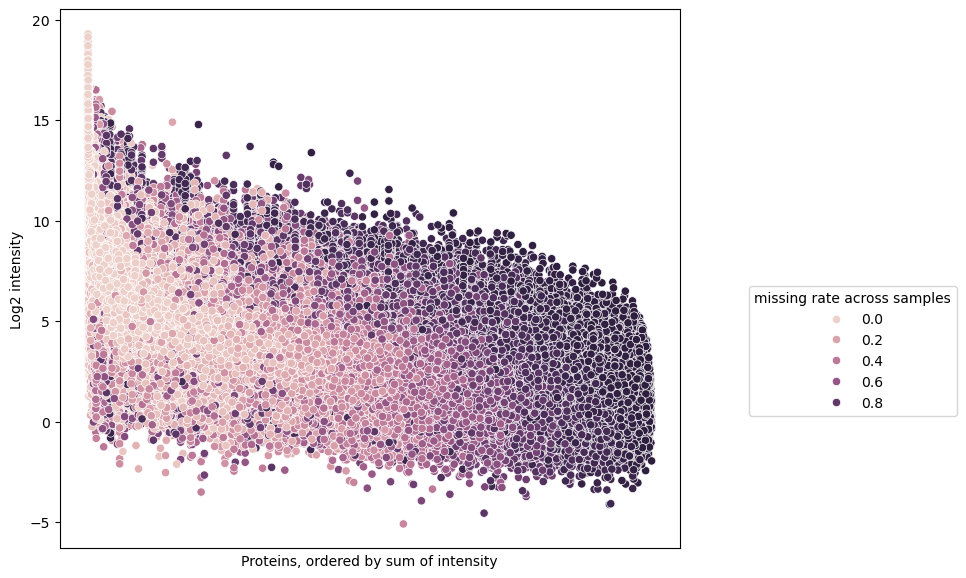

In [19]:
plot_qc(adata)

<Axes: title={'center': 'Sample completeness (layer: None)'}, xlabel='Samples', ylabel='Completeness (fraction non-missing)'>

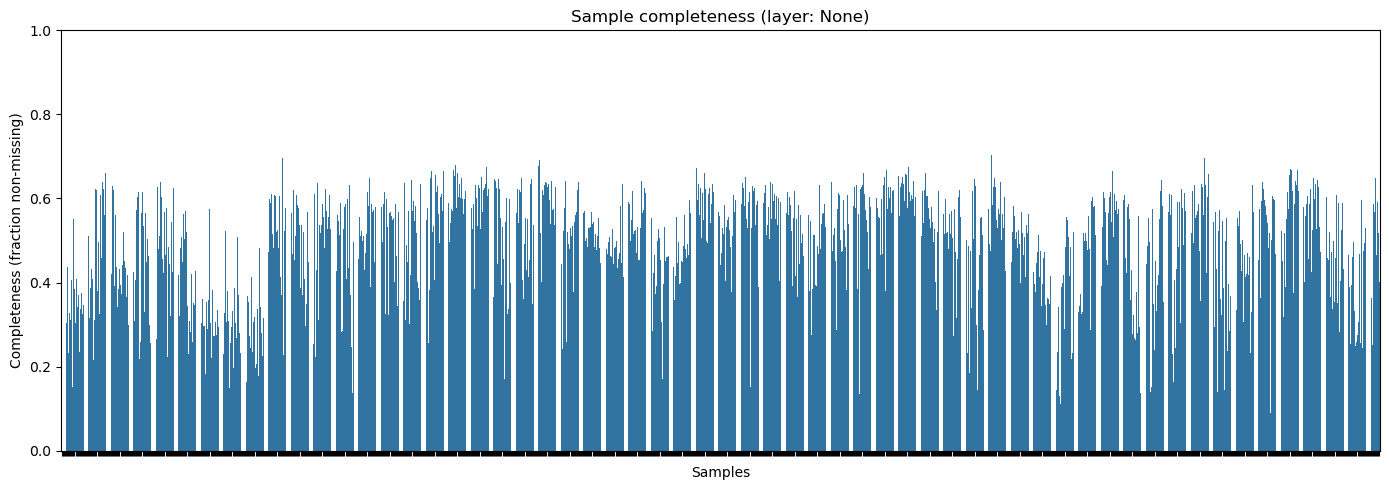

In [20]:
plot_sample_completeness(adata)

In [23]:
adata = proteome_2_anndata(proteome_df = proteome_df, 
                           metadata_df = metadata_df,
                           match_sample_column="SampleID",
                           match_protein_column="UniprotID",
                           protein_annotation_columns=["UniprotID"],
                           need_log2=False,
                           log2_intensity_threshold=-2.5)
adata

INFO: Removed 20 rows where all sample columns were NA.
INFO: Applying threshold control with log2 intensity threshold = -2.5
INFO: AnnData object successfully created and returned.


AnnData object with n_obs × n_vars = 1260 × 9082
    obs: 'index', 'Cancer type', 'Tissue type', 'Cancer subtype'
    uns: 'intensity_threshold'
    obsm: 'number_detection_sample', 'missing_rate_sample'
    varm: 'missing_rate_gene', 'median_intensity', 'sum_intensity'
    layers: 'median_norm', 'threshold_removed', 'threshold_added', 'median_norm_threshold_added', 'threshold_controlled', 'median_norm_threshold_controlled'

In [24]:
adata.write(os.path.join(data_output_dir, "PanCancer_Cai2025_FDL.h5ad"))

... storing 'Cancer type' as categorical
... storing 'Tissue type' as categorical
... storing 'Cancer subtype' as categorical
